נטענו 55117 שורות נתונים
קובץ test_yolo_dataset.csv נשמר בהצלחה.
מספר דוגמאות: 28174 | מספר מאפיינים: 24
מספר קלאסים לברך: 3, למרפק: 3
Epoch 1/300


C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


564/564 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - dominant_elbow_accuracy: 0.4257 - dominant_elbow_loss: 1.1361 - dominant_knee_accuracy: 0.5170 - dominant_knee_loss: 1.0928 - loss: 8.2175 - movement_score_loss: 5.9886 - movement_score_mae: 1.7478
Epoch 1: val_loss improved from inf to 3.85040, saving model to best_yolo_infant_movement_model_3class.keras
564/564 ━━━━━━━━━━━━━━━━━━━━ 19s 25ms/step - dominant_elbow_accuracy: 0.4258 - dominant_elbow_loss: 1.1360 - dominant_knee_accuracy: 0.5170 - dominant_knee_loss: 1.0927 - loss: 8.2119 - movement_score_loss: 5.9832 - movement_score_mae: 1.7469 - val_dominant_elbow_accuracy: 0.4652 - val_dominant_elbow_loss: 1.0053 - val_dominant_knee_accuracy: 0.6098 - val_dominant_knee_loss: 0.9035 - val_loss: 3.8504 - val_movement_score_loss: 1.9414 - val_movement_score_mae: 1.0837 - learning_rate: 0.0010
Epoch 2/300
562/564 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - dominant_elbow_accuracy: 0.4638 - dominant_elbow_loss: 1.0231 - dominant_knee_accuracy: 0.6023 - d

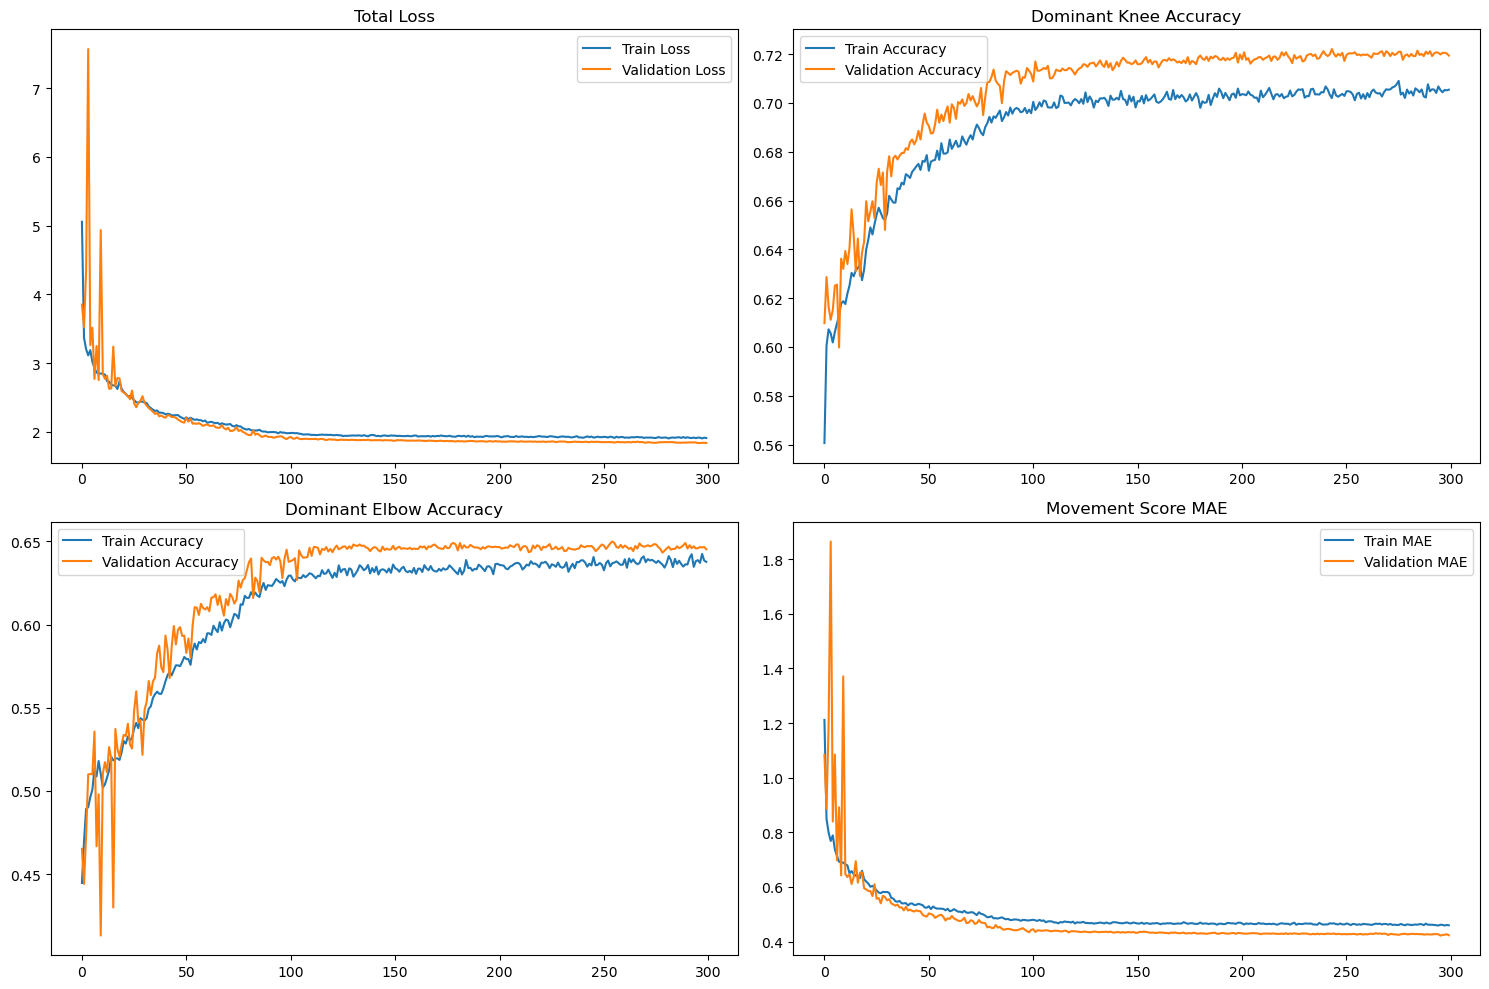

המודל נשמר בהצלחה כקובץ 'infant_yolo_movement_gru_model_3class.keras'

האימון הסתיים בהצלחה!


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import GRU, Dense, Input, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, accuracy_score, classification_report
import os

from tensorflow.keras.layers import LeakyReLU, ReLU

# פרמטרים
WINDOW_SIZE = 30
RANDOM_STATE = 42
BATCH_SIZE = 32
EPOCHS = 300
LEARNING_RATE = 0.001

def create_dominance_labels(df, knee_threshold=None, elbow_threshold=None):
    """יוצר עמודות דומיננטיות עם 3 קלאסים: 0=right, 1=left, 2=no dominance"""
    if knee_threshold is None:
        knee_threshold = df[['right_knee_score','left_knee_score']].max(axis=1).median() * 0.1
    if elbow_threshold is None:
        elbow_threshold = df[['right_elbow_score','left_elbow_score']].max(axis=1).median() * 0.1

    def get_class(right, left, thr):
        diff = abs(right - left)
        if diff < thr:
            return 2
        return 0 if right > left else 1

    df['dominant_knee'] = df.apply(lambda r: get_class(r['right_knee_score'], r['left_knee_score'], knee_threshold), axis=1)
    df['dominant_elbow'] = df.apply(lambda r: get_class(r['right_elbow_score'], r['left_elbow_score'], elbow_threshold), axis=1)
    return df

def load_and_preprocess_data(file_paths, window_size=WINDOW_SIZE):
    all_data, test_data = [], []
    for file_path in file_paths:
        df = pd.read_csv(file_path) if file_path.endswith('.csv') else pd.read_excel(file_path)
        required_columns = ['video_id','frame','window_id','overall_movement_score','right_knee_score','left_knee_score','right_elbow_score','left_elbow_score']
        if not all(col in df.columns for col in required_columns):
            print(f"The file {file_path} is missing required columns. Skipping...")
            continue
        test_subset = df[df['video_id'].isin([43, 44])]
        if not test_subset.empty:
            test_data.append(test_subset)
        df = df[~df['video_id'].isin([43, 44])]
        df = create_dominance_labels(df)
        all_data.append(df)
    if not all_data:
        raise ValueError("No valid files found for processing")
    data = pd.concat(all_data, ignore_index=True)
    return data, test_data

def prepare_sequences(data, window_size=WINDOW_SIZE):
    feature_columns = [col for col in data.columns if any(x in col for x in ['_x','_y','_confidence']) and not any(skip in col.lower() for skip in ['velocity','angle'])]
    X, y_movement, y_knee, y_elbow = [], [], [], []
    for (vid_id, win_id), group in data.groupby(['video_id','window_id']):
        if len(group) < window_size:
            continue
        for i in range(0, len(group)-window_size+1):
            seq = group.iloc[i:i+window_size][feature_columns].values
            target = group.iloc[i+window_size-1]
            X.append(seq)
            y_movement.append(target['overall_movement_score'])
            y_knee.append(target['dominant_knee'])
            y_elbow.append(target['dominant_elbow'])
    return np.array(X), np.array(y_movement), np.array(y_knee), np.array(y_elbow), feature_columns

def build_gru_model(input_shape, num_knee_classes, num_elbow_classes):
    inputs = Input(shape=input_shape)
    x = GRU(128, return_sequences=True)(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = GRU(64)(x)
    x = BatchNormalization()(x)
    shared = Dropout(0.3)(x)
    movement_output = Dense(32, activation='relu')(shared)
    movement_output = Dense(1)(movement_output)
    movement_output = ReLU(max_value=10, name='movement_score')(movement_output)
    knee_output = Dense(32)(shared)
    knee_output = LeakyReLU(alpha=0.01)(knee_output)
    knee_output = Dense(num_knee_classes, activation='softmax', name='dominant_knee')(knee_output)
    elbow_output = Dense(32)(shared)
    elbow_output = LeakyReLU(alpha=0.01)(elbow_output)
    elbow_output = Dense(num_elbow_classes, activation='softmax', name='dominant_elbow')(elbow_output)
    model = Model(inputs=inputs, outputs=[movement_output, knee_output, elbow_output])
    model.compile(optimizer=Adam(learning_rate=LEARNING_RATE),
                  loss={'movement_score':'mse','dominant_knee':'sparse_categorical_crossentropy','dominant_elbow':'sparse_categorical_crossentropy'},
                  metrics={'movement_score':['mae'],'dominant_knee':['accuracy'],'dominant_elbow':['accuracy']})
    return model

def train_model(X_train, y_train, X_val, y_val, input_shape, num_knee_classes, num_elbow_classes):
    model = build_gru_model(input_shape, num_knee_classes, num_elbow_classes)
    callbacks=[EarlyStopping(monitor='val_loss',patience=50,restore_best_weights=True),
               ReduceLROnPlateau(monitor='val_loss',factor=0.5,patience=5,min_lr=1e-5),
               ModelCheckpoint('best_yolo_infant_movement_model_3class.keras', monitor='val_loss',save_best_only=True,verbose=1)]
    history=model.fit(X_train,y_train,batch_size=BATCH_SIZE,epochs=EPOCHS,validation_data=(X_val,y_val),callbacks=callbacks,verbose=1)
    return model, history

def evaluate_model(model, X_test, y_test_movement, y_test_knee, y_test_elbow):
    y_pred_movement,y_pred_knee_prob,y_pred_elbow_prob=model.predict(X_test)
    y_pred_knee=np.argmax(y_pred_knee_prob,axis=1)
    y_pred_elbow=np.argmax(y_pred_elbow_prob,axis=1)
    mse=mean_squared_error(y_test_movement,y_pred_movement)
    rmse=np.sqrt(mse)
    knee_acc=accuracy_score(y_test_knee,y_pred_knee)
    elbow_acc=accuracy_score(y_test_elbow,y_pred_elbow)
    print("\n===== תוצאות המודל =====")
    print(f"RMSE for motion score: {rmse:.4f}")
    print(f"דיוק סיווג ברך דומיננטית: {knee_acc:.4f}")
    print(f"דיוק סיווג מרפק דומיננטי: {elbow_acc:.4f}")
    print("\nדוח סיווג - ברך דומיננטית:")
    print(classification_report(y_test_knee,y_pred_knee))
    print("\nדוח סיווג - מרפק דומיננטי:")
    print(classification_report(y_test_elbow,y_pred_elbow))
    return {'rmse_movement':rmse,'knee_accuracy':knee_acc,'elbow_accuracy':elbow_acc}

def plot_training_history(history):
    fig,axes=plt.subplots(2,2,figsize=(15,10))
    axes[0,0].plot(history.history['loss'],label='Train Loss')
    axes[0,0].plot(history.history['val_loss'],label='Validation Loss')
    axes[0,0].set_title('Total Loss'); axes[0,0].legend()
    axes[0,1].plot(history.history['dominant_knee_accuracy'],label='Train Accuracy')
    axes[0,1].plot(history.history['val_dominant_knee_accuracy'],label='Validation Accuracy')
    axes[0,1].set_title('Dominant Knee Accuracy'); axes[0,1].legend()
    axes[1,0].plot(history.history['dominant_elbow_accuracy'],label='Train Accuracy')
    axes[1,0].plot(history.history['val_dominant_elbow_accuracy'],label='Validation Accuracy')
    axes[1,0].set_title('Dominant Elbow Accuracy'); axes[1,0].legend()
    axes[1,1].plot(history.history['movement_score_mae'],label='Train MAE')
    axes[1,1].plot(history.history['val_movement_score_mae'],label='Validation MAE')
    axes[1,1].set_title('Movement Score MAE'); axes[1,1].legend()
    plt.tight_layout(); plt.savefig('training_history_3class.png'); plt.show()

def main():
    file_paths=['yolo_dataset.csv']
    if not os.path.exists('yolo_dataset.csv'):
        print("שגיאה: הקובץ 'yolo_dataset.csv' לא נמצא")
        return
    try:
        data,test_data=load_and_preprocess_data(file_paths)
        print(f"נטענו {len(data)} שורות נתונים")
    except Exception as e:
        print(f"שגיאה בטעינת הנתונים: {e}")
        return
    if test_data:
        test_df=pd.concat(test_data,ignore_index=True)
        test_df.to_csv('test_yolo_dataset.csv',index=False)
        print("קובץ test_yolo_dataset.csv נשמר בהצלחה.")
    X,y_movement,y_knee,y_elbow,feature_columns=prepare_sequences(data)
    print(f"מספר דוגמאות: {len(X)} | מספר מאפיינים: {X.shape[2]}")
    num_knee_classes=len(np.unique(y_knee))
    num_elbow_classes=len(np.unique(y_elbow))
    print(f"מספר קלאסים לברך: {num_knee_classes}, למרפק: {num_elbow_classes}")
    X_train_val,X_test,y_movement_train_val,y_movement_test,y_knee_train_val,y_knee_test,y_elbow_train_val,y_elbow_test=train_test_split(X,y_movement,y_knee,y_elbow,test_size=0.2,random_state=RANDOM_STATE)
    X_train,X_val,y_movement_train,y_movement_val,y_knee_train,y_knee_val,y_elbow_train,y_elbow_val=train_test_split(X_train_val,y_movement_train_val,y_knee_train_val,y_elbow_train_val,test_size=0.2,random_state=RANDOM_STATE)
    input_shape=(X_train.shape[1],X_train.shape[2])
    y_train=[y_movement_train,y_knee_train,y_elbow_train]
    y_val=[y_movement_val,y_knee_val,y_elbow_val]
    model,history=train_model(X_train,y_train,X_val,y_val,input_shape,num_knee_classes,num_elbow_classes)
    evaluate_model(model,X_test,y_movement_test,y_knee_test,y_elbow_test)
    plot_training_history(history)
    model.save('infant_yolo_movement_gru_model_3class.keras')
    print("המודל נשמר בהצלחה כקובץ 'infant_yolo_movement_gru_model_3class.keras'")
    with open('model_features_3class.txt','w') as f:
        f.write('\n'.join(feature_columns))
    print("\nהאימון הסתיים בהצלחה!")

if __name__ == "__main__":
    main()
